In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import interp1d

In [11]:
## -- load fitted LD coefficients
s1_wavesR100, s1_wavehwsR100, s1_u1, s1_u1err, s1_u2, s1_u2err = np.loadtxt("./data/spectra/V1298Tauc_SOSS_LCtest1_logLD_LDcoefficients_R100.txt", skiprows=1, unpack=True)
s2_wavesR100, s2_wavehwsR100, s2_u1, s2_u1err, s2_u2, s2_u2err = np.loadtxt("./data/spectra/V1298Tauc_SOSS_LCtest2_logLD_LDcoefficients_R100.txt", skiprows=1, unpack=True)
s4_wavesR100, s4_wavehwsR100, s4_u1, s4_u1err, s4_u2, s4_u2err = np.loadtxt("./data/spectra/V1298Tauc_SOSS_LCtest4_logLD_LDcoefficients_R100.txt", skiprows=1, unpack=True)

## -- load in model limb darkening coeffiient spectra
## LOGARITHMIC
## ATLAS, via ExoCTK 
# 0 = wavelength, 1 = u1, 2 = u1 uncertainty, 3 = u2, 4 = u2 uncertainty
ldc_atlas = np.loadtxt('./data/limbdark/LDCs_V1298tau_logarithmic_exoctkATLAS.csv', delimiter=' ', unpack=True, skiprows=21, usecols=[6, 8, 9, 10, 11])
a_interp1 = interp1d(x=ldc_atlas[0], y=ldc_atlas[1], bounds_error=None, fill_value='extrapolate')
a_interp2 = interp1d(x=ldc_atlas[0], y=ldc_atlas[3], bounds_error=None, fill_value='extrapolate')

a_du1 = a_interp1(s2_wavesR100)
a_du2 = a_interp2(s2_wavesR100)

## PHOENIX, via ExoCTK
# 0 = wavelength, 1 = u1, 2 = u1 uncertainty, 3 = u2, 4 = u2 uncertainty
ldc_phoenix = np.loadtxt('./data/limbdark/LDCs_V1298tau_logarithmic_exoctkPHOENIX.csv', delimiter=' ', unpack=True, skiprows=21, usecols=[6, 8, 9, 10, 11])
p_interp1 = interp1d(x=ldc_phoenix[0], y=ldc_phoenix[1], bounds_error=None, fill_value='extrapolate')
p_interp2 = interp1d(x=ldc_phoenix[0], y=ldc_phoenix[3], bounds_error=None, fill_value='extrapolate')

p_du1 = p_interp1(s2_wavesR100)
p_du2 = p_interp2(s2_wavesR100)

In [12]:
c1 = '#0652FF'
c2 = 'green'
c4 = '#FFAB0F'

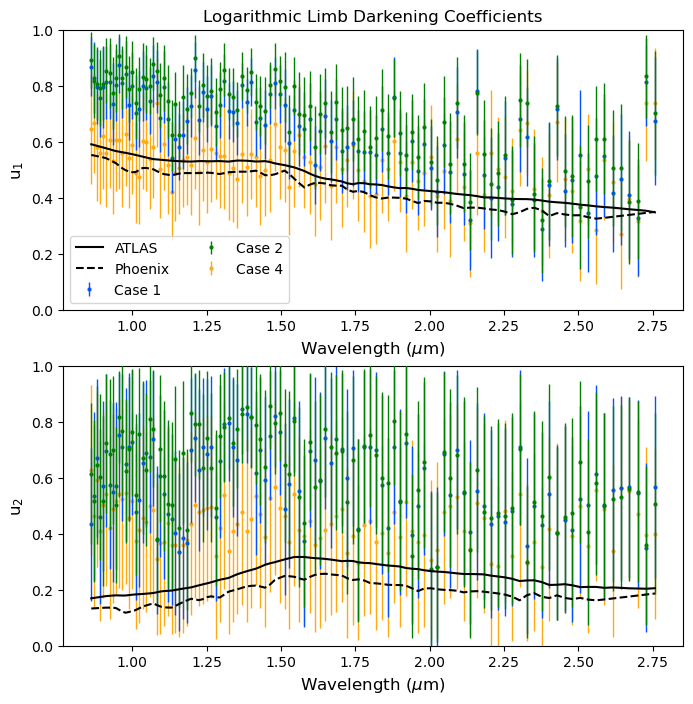

In [13]:
## -- logarithmic:
fig, ax = plt.subplots(figsize=(8,8), nrows=2)
# top: u1
ax[0].set_title(r'Logarithmic Limb Darkening Coefficients', fontsize=12)
ax[0].errorbar(s1_wavesR100, s1_u1, s1_u1err, c=c1, lw=1, ls='None', marker='o', ms=2, zorder=2, label='Case 1')
ax[0].errorbar(s2_wavesR100, s2_u1, s2_u1err, c=c2, lw=1, ls='None', marker='o', ms=2, zorder=3, label='Case 2')
ax[0].errorbar(s4_wavesR100, s4_u1, s4_u1err, c=c4, lw=1, ls='None', marker='o', ms=2, zorder=1, label='Case 4')
ax[0].plot(s2_wavesR100, a_du1, c='black', zorder=4, label='ATLAS')
ax[0].plot(s2_wavesR100, p_du1, c='black', ls='--', zorder=4, label='Phoenix')
ax[0].set_ylabel(r'u$_1$', fontsize=12)
ax[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[0].legend(loc='best', ncol=2)
ax[0].set_ylim(0,1)
# top: u2
ax[1].errorbar(s1_wavesR100, s1_u2, s1_u2err, c=c1, lw=1, ls='None', marker='o', ms=2, zorder=2, label='Case 1')
ax[1].errorbar(s2_wavesR100, s2_u2, s2_u2err, c=c2, lw=1, ls='None', marker='o', ms=2, zorder=3, label='Case 2')
ax[1].errorbar(s4_wavesR100, s4_u2, s4_u2err, c=c4, lw=1, ls='None', marker='o', ms=2, zorder=1, label='Case 4')
ax[1].plot(s2_wavesR100, a_du2, c='black', zorder=4, label='ATLAS')
ax[1].plot(s2_wavesR100, p_du2, c='black', ls='--', zorder=4, label='Phoenix')
ax[1].set_ylabel(r'u$_2$', fontsize=12)
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylim(0,1)
plt.savefig('./figures/Figure11.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure11.pdf', dpi=600, format='PDF', bbox_inches='tight')
plt.show()